In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
plt.style.use('fivethirtyeight')

In [2]:
end = datetime.now()
start = datetime(end.year-15, end.month, end.day)
stock = 'BTC-USD'
stock_data = yf.download(stock, start=start, end = end)

[*********************100%***********************]  1 of 1 completed


In [3]:
stock_data.head()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800
2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200
2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700
2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600
2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100


In [4]:
stock_data.tail()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2026-04-23,78268.953125,78676.937500,77014.453125,78203.875000,40354900916
2026-04-24,77455.312500,78554.093750,77318.445312,78263.820312,32784213526
2026-04-25,77612.015625,77882.640625,77184.664062,77457.210938,16702933134
2026-04-26,78657.539062,78923.562500,77334.890625,77613.117188,21482934750
2026-04-27,77049.703125,79420.273438,76579.789062,78670.851562,38562299904


In [5]:
stock_data.describe().T

,,count,mean,std,min,25%,50%,75%,max
Price,Ticker,,,,,,,,
Close,BTC-USD,4241.0,2.819883e+04,3.226373e+04,1.781030e+02,3.342470e+03,1.139238e+04,4.469536e+04,1.247525e+05
High,BTC-USD,4241.0,2.874454e+04,3.280677e+04,2.117310e+02,3.427946e+03,1.165720e+04,4.620393e+04,1.261981e+05
Low,BTC-USD,4241.0,2.758489e+04,3.166932e+04,1.715100e+02,3.233820e+03,1.113610e+04,4.347516e+04,1.231960e+05
Open,BTC-USD,4241.0,2.818179e+04,3.225849e+04,1.768970e+02,3.311752e+03,1.138505e+04,4.457828e+04,1.247521e+05
Volume,BTC-USD,4241.0,2.219260e+10,2.298918e+10,5.914570e+06,1.534510e+09,1.777008e+10,3.436356e+10,3.509679e+11


In [6]:
stock_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4241 entries, 2014-09-17 to 2026-04-27
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Close, BTC-USD)   4241 non-null   float64
 1   (High, BTC-USD)    4241 non-null   float64
 2   (Low, BTC-USD)     4241 non-null   float64
 3   (Open, BTC-USD)    4241 non-null   float64
 4   (Volume, BTC-USD)  4241 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 198.8 KB


In [7]:
stock_data.columns

MultiIndex([( 'Close', 'BTC-USD'),
            (  'High', 'BTC-USD'),
            (   'Low', 'BTC-USD'),
            (  'Open', 'BTC-USD'),
            ('Volume', 'BTC-USD')],
           names=['Price', 'Ticker'])

In [8]:
#Close price data
closing_price = stock_data[['Close']]

In [9]:
closing_price['Close']

Ticker,BTC-USD
Date,
2014-09-17,457.334015
2014-09-18,424.440002
2014-09-19,394.795990
2014-09-20,408.903992
2014-09-21,398.821014
...,...
2026-04-23,78268.953125
2026-04-24,77455.312500
2026-04-25,77612.015625


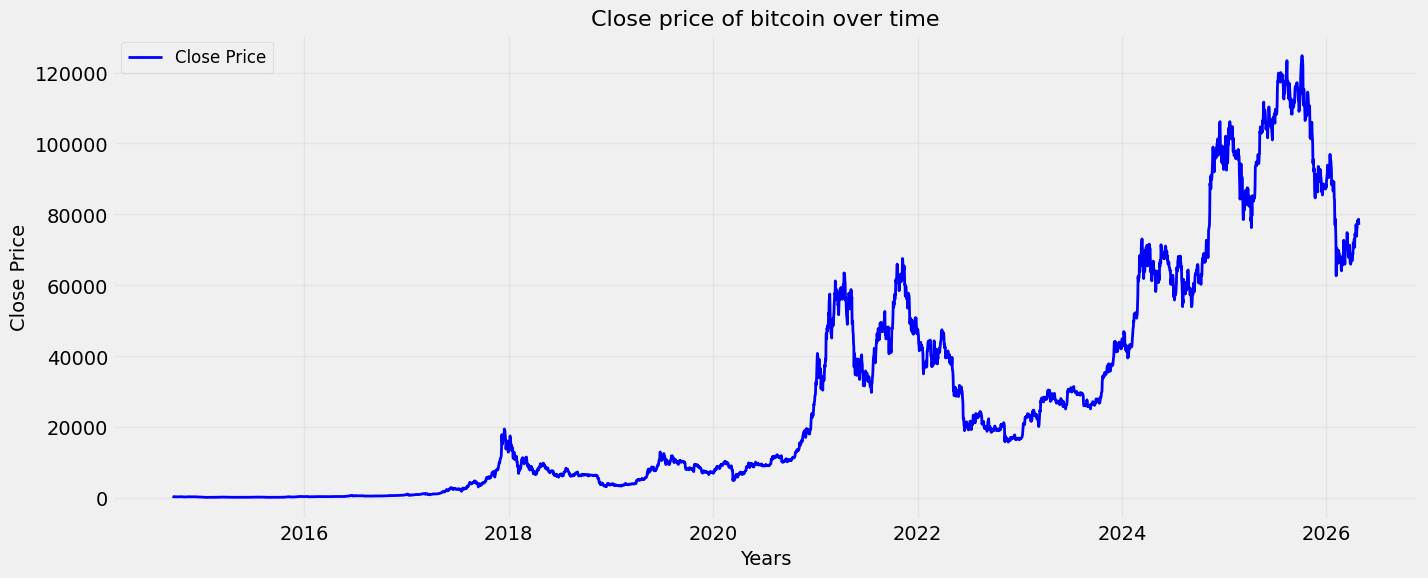

In [10]:
#Plot closing price with enchacement
plt.figure(figsize = (15, 6))
plt.plot(closing_price.index, closing_price['Close'], label = 'Close Price', color = 'blue', linewidth =2)
plt.title("Close price of bitcoin over time", fontsize = 16)
plt.xlabel("Years", fontsize = 14)
plt.ylabel('Close Price', fontsize = 14)
plt.grid(alpha = 0.3)
plt.legend(fontsize = 12)
plt.show()

In [11]:
# Moving Average
temp_data = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
# moving average for 5 day -> null null null null 30.0 40.0
print(sum(temp_data[1:6])/5)

40.0


In [12]:
df1 = pd.DataFrame(temp_data)

In [13]:
df1.rolling(5).mean()

,0
0,NaN
1,NaN
2,NaN
3,NaN
4,30.0
5,40.0
6,50.0
7,60.0
8,70.0
9,80.0


In [14]:
for i in range(2014, 2024):
    print(i, list(stock_data.index.year).count(i))

2014 106
2015 365
2016 366
2017 365
2018 365
2019 365
2020 366
2021 365
2022 365
2023 365


In [15]:
closing_price['MA_365'] = closing_price['Close'].rolling(window = 365).mean()
closing_price['MA_100'] = closing_price['Close'].rolling(window = 100).mean()

C:\Users\adity\AppData\Local\Temp\ipykernel_23352\194502310.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  closing_price['MA_365'] = closing_price['Close'].rolling(window = 365).mean()
C:\Users\adity\AppData\Local\Temp\ipykernel_23352\194502310.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  closing_price['MA_100'] = closing_price['Close'].rolling(window = 100).mean()


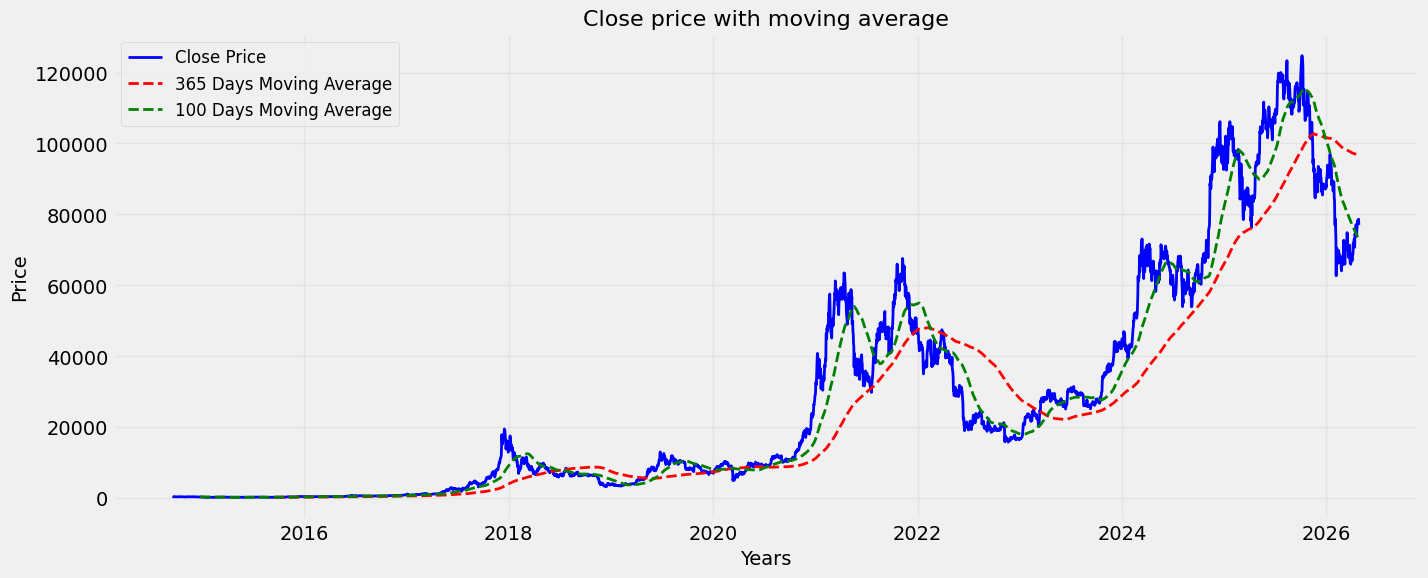

In [16]:
#Plot closing price with enchacement
plt.figure(figsize = (15, 6))
plt.plot(closing_price.index, closing_price['Close'], label = 'Close Price', color = 'blue', linewidth =2)
plt.plot(closing_price.index, closing_price['MA_365'], label = '365 Days Moving Average', color = 'red', linestyle ="--", linewidth =2)
plt.plot(closing_price.index, closing_price['MA_100'], label = '100 Days Moving Average', color = 'green',linestyle ="--", linewidth =2)

plt.title("Close price with moving average", fontsize = 16)
plt.xlabel("Years", fontsize = 14)
plt.ylabel('Price', fontsize = 14)
plt.grid(alpha = 0.3)
plt.legend(fontsize = 12)
plt.show()

In [17]:
# LSTM-> Long short term memory
# scale the data
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(closing_price[['Close']].dropna())

In [18]:
len(scaled_data)

4241

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, LSTM

In [ ]:
# Prepare data for lstm
x_data = []
y_data = []
base_days =100
for i in range(base_days, len(scaled_data)):
    x_data.append(scaled_data[i-base_days: i])
    y_data.append(scaled_data[i])
x_data = np.array(x_data)
y_data = np.array(y_data)

In [ ]:
# Split into train and test sets
train_size = int(len(x_data) * 0.9)
x_train , y_train = x_data[:train_size], y_data[:train_size]
x_test, y_test = x_data[train_size:], y_data[train_size:]

In [ ]:
model = Sequential([
    LSTM(128, return_sequences = True, input_shape = (x_train.shape[1], 1)),
    LSTM(64, return_sequences = False),
    Dense(25),
    Dense(1)
])

model.compile(optimizer = "adam", loss = "mean_squared_error")
model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 100, 128)          66560     
                                                                 
 lstm_1 (LSTM)               (None, 64)                49408     
                                                                 
 dense (Dense)               (None, 25)                1625      
                                                                 
 dense_1 (Dense)             (None, 1)                 26        
                                                                 
Total params: 117619 (459.45 KB)
Trainable params: 117619 (459.45 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
model.fit(x_train, y_train, batch_size = 5, epochs = 10)

Epoch 1/10

744/744 [==============================] - 44s 52ms/step - loss: 7.2903e-04
Epoch 2/10
744/744 [==============================] - 37s 50ms/step - loss: 2.8839e-04
Epoch 3/10
744/744 [==============================] - 36s 49ms/step - loss: 2.0686e-04
Epoch 4/10
744/744 [==============================] - 38s 51ms/step - loss: 1.8404e-04
Epoch 5/10
744/744 [==============================] - 42s 56ms/step - loss: 1.4402e-04
Epoch 6/10
744/744 [==============================] - 37s 49ms/step - loss: 1.6593e-04
Epoch 7/10
744/744 [==============================] - 36s 49ms/step - loss: 1.4083e-04
Epoch 8/10
744/744 [==============================] - 39s 52ms/step - loss: 1.1413e-04
Epoch 9/10
744/744 [==============================] - 38s 51ms/step - loss: 1.1966e-04
Epoch 10/10
744/744 [==============================] - 39s 53ms/step - loss: 1.3108e-04


In [ ]:
predictions = model.predict(x_test)
inv_predictions = scaler.inverse_transform(predictions)
inv_y_test = scaler.inverse_transform(y_test)

13/13 [==============================] - 1s 32ms/step


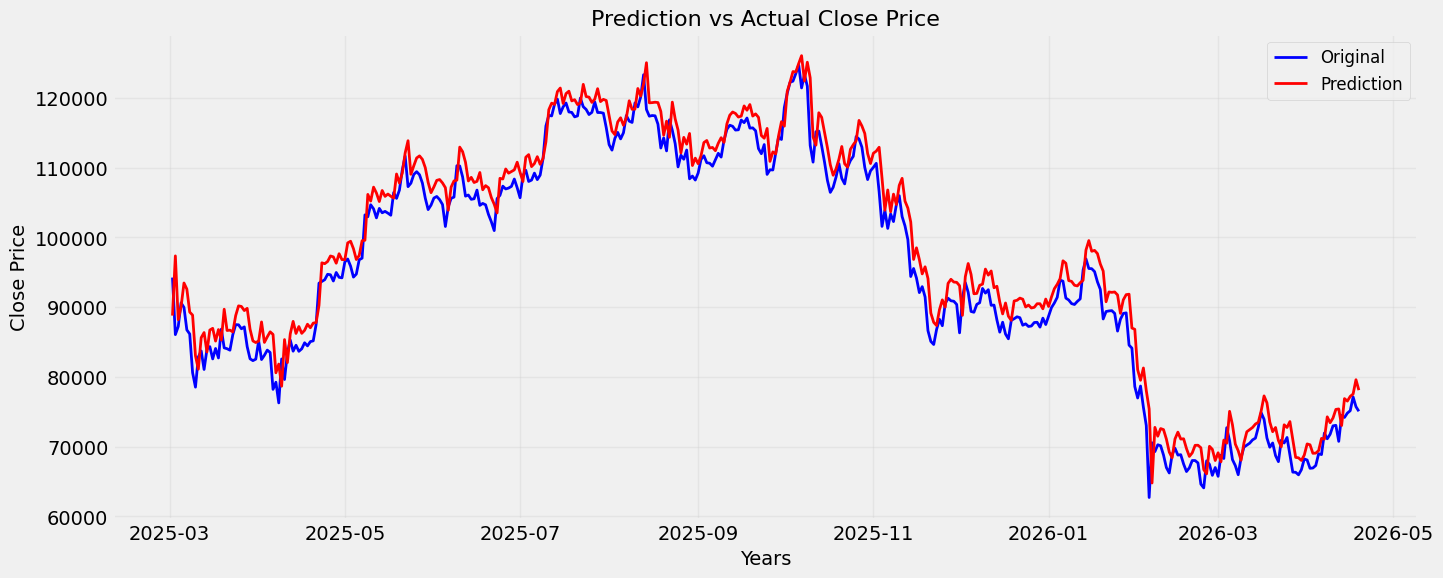

In [ ]:
plotting_data = pd.DataFrame(
    {
        'Original': inv_y_test.flatten(), 
        'Prediction': inv_predictions.flatten(),
    }, index = closing_price.index[train_size + base_days:]
)

plt.figure(figsize = (15, 6))
plt.plot(plotting_data.index, plotting_data['Original'], label = 'Original', color = 'blue', linewidth =2)
plt.plot(plotting_data.index, plotting_data['Prediction'], label = 'Prediction', color = 'red',  linewidth =2)

plt.title("Prediction vs Actual Close Price", fontsize = 16)
plt.xlabel("Years", fontsize = 14)
plt.ylabel('Close Price', fontsize = 14)
plt.grid(alpha = 0.3)
plt.legend(fontsize = 12)
plt.show()

In [ ]:
# Predict future days
last_100  = scaled_data[-100:].reshape(1, -1, 1)
future_predictions=[]
for _ in range(10):
    next_days = model.predict(last_100)
    future_predictions.append(scaler.inverse_transform(next_days))
    last_100 = np.append(last_100[:, 1:, :], next_days.reshape(1, 1, -1), axis = 1)

1/1 [==============================] - 0s 39ms/step


In [ ]:
future_predictions

[array([[77452.42]], dtype=float32),
 array([[79929.62]], dtype=float32),
 array([[82472.29]], dtype=float32),
 array([[85088.48]], dtype=float32),
 array([[87755.35]], dtype=float32),
 array([[90454.266]], dtype=float32),
 array([[93166.914]], dtype=float32),
 array([[95873.57]], dtype=float32),
 array([[98553.266]], dtype=float32),
 array([[101185.05]], dtype=float32)]

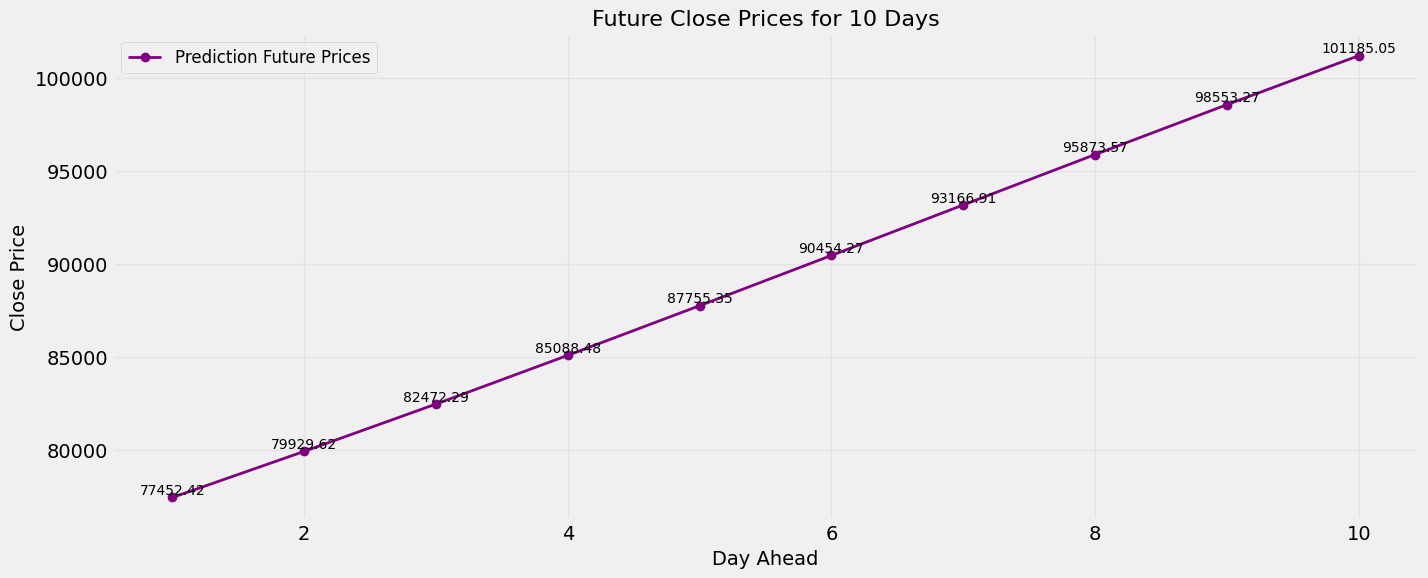

In [ ]:
future_predictions = np.array(future_predictions).flatten()

plt.figure(figsize = (15, 6))
plt.plot(range(1, 11), future_predictions, marker="o" ,label = 'Prediction Future Prices', color = 'purple', linewidth =2)

for i, val in enumerate(future_predictions):
    plt.text(i+1,val,  f'{val:.2f}', fontsize = 10, ha = 'center', va = 'bottom', color='black')

plt.title("Future Close Prices for 10 Days", fontsize = 16)
plt.xlabel("Day Ahead", fontsize = 14)
plt.ylabel('Close Price', fontsize = 14)
plt.grid(alpha = 0.3)
plt.legend(fontsize = 12)
plt.show()

In [ ]:
model.save("model.keras")

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Example variables
# y_test = actual values
# predictions = model predictions

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)

mape = np.mean(np.abs((y_test - predictions) / y_test)) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)
print("Approx Accuracy:", 100 - mape)

MAE: 0.021492220041071035
RMSE: 0.025763742134030373
MAPE: 2.9632404920365496
Approx Accuracy: 97.03675950796345
